# Financial Sentiment Classifier: Domain-Adapted DistilBERT

General-purpose sentiment models are trained on product reviews, tweets, and movie ratings — none of which look like analyst reports. A phrase like *"the company issued a profit warning"* registers as ambiguous or even positive to a general model because "profit" is a positive word. To a finance professional, it signals bad news.

This notebook fine-tunes DistilBERT on the Financial PhraseBank dataset (Malo et al., 2013) — 3,453 sentences from analyst reports hand-labelled as **positive**, **negative**, or **neutral** by finance researchers. We then prove the domain adaptation actually helps by comparing against a VADER baseline.

## 1. Setup & Dependencies

In [1]:
!pip install transformers>=4.40.0 datasets>=2.19.0 scikit-learn>=1.4.0 vaderSentiment>=3.3.2 accelerate>=0.29.0 -q

zsh:1: 4.40.0 not found


In [3]:
import random
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: mps
PyTorch version: 2.12.0


## 2. Data Loading & Exploratory Analysis

We use `Sentences_75Agree.txt` — sentences where at least 75% of annotators agreed on the label. This gives 3,453 sentences with high signal quality. The 50% agreement file has more data but introduces more label noise; the 100% agreement file only has 2,264 sentences, which is thin for fine-tuning.

In [5]:
DATA_PATH = 'FinancialPhraseBank-v1.0/Sentences_75Agree.txt'

sentences, labels = [], []
with open(DATA_PATH, encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        if not line or '@' not in line:
            continue
        # Format: sentence text@label  (last @ is the separator)
        last_at = line.rfind('@')
        sentences.append(line[:last_at].strip())
        labels.append(line[last_at + 1:].strip())

df = pd.DataFrame({'sentence': sentences, 'label': labels})
print(f'Total samples: {len(df)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Total samples: 3453
Label distribution:
label
neutral     2146
positive     887
negative     420
Name: count, dtype: int64


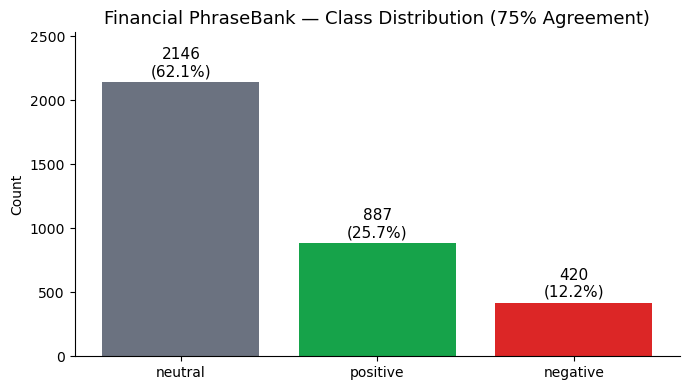

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['label'].value_counts()
colors = {'neutral': '#6b7280', 'positive': '#16a34a', 'negative': '#dc2626'}
bars = ax.bar(counts.index, counts.values, color=[colors[l] for l in counts.index])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Financial PhraseBank — Class Distribution (75% Agreement)', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
# Sample sentences to illustrate why financial language is hard
for label in ['positive', 'negative', 'neutral']:
    sample = df[df['label'] == label]['sentence'].sample(3, random_state=SEED).tolist()
    print(f'\n--- {label.upper()} ---')
    for s in sample:
        print(f'  • {s}')


--- POSITIVE ---
  • Revenue grew 1 percent to euro742 .2 million US$ 964 million from euro735 million .
  • Luxembourg-registered investment fund Amber Trust II has won the final approval of Lithuania 's Competition Council to acquire 29.6 percent of Sanitas , the country 's largest pharmaceutical producer .
  • The company is also featured in the Ethibel Pioneer Investment Register and included in Innovest 's Global 100 list of the world 's most sustainable corporations .

--- NEGATIVE ---
  • The situation of coated magazine printing paper will continue to be weak .
  • Alma Media 's operating profit amounted to EUR 11.9 mn , down from EUR 15.0 mn a year earlier .
  • Reported operating margin was a negative 5.9 % .

--- NEUTRAL ---
  • Thanks to its extensive industry and operations experience , Cybercom offers strategic and technological expertise to these markets : telecom , industry , media , public sector , retail , and banking and financial services .
  • The company is repor

## 3. Baseline: VADER (Rule-Based General Sentiment)

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based model built for social media text. It has no knowledge of financial language. Establishing its performance here creates the benchmark we need to beat.

Mapping VADER's compound score to three classes: `compound > 0.05` → positive, `< -0.05` → negative, otherwise → neutral.

In [11]:
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = analyzer.polarity_scores(text)['compound']
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    return 'neutral'

df['vader_pred'] = df['sentence'].apply(vader_predict)

print('VADER Baseline Performance:')
print('=' * 55)
vader_report = classification_report(
    df['label'], df['vader_pred'],
    labels=['positive', 'negative', 'neutral'],
    output_dict=True
)
print(classification_report(
    df['label'], df['vader_pred'],
    labels=['positive', 'negative', 'neutral']
))

VADER Baseline Performance:
              precision    recall  f1-score   support

    positive       0.39      0.73      0.51       887
    negative       0.39      0.28      0.33       420
     neutral       0.80      0.55      0.65      2146

    accuracy                           0.56      3453
   macro avg       0.52      0.52      0.49      3453
weighted avg       0.64      0.56      0.57      3453



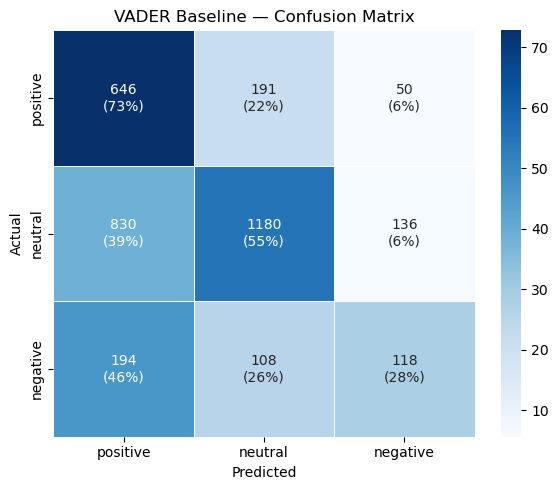

In [13]:
def plot_confusion_matrix(y_true, y_pred, title, label_order=None):
    if label_order is None:
        label_order = ['positive', 'neutral', 'negative']
    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)'  
                       for j in range(len(label_order))]
                      for i in range(len(label_order))])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(df['label'], df['vader_pred'], 'VADER Baseline — Confusion Matrix')

## 4. Train / Validation / Test Split

Stratified split to maintain class proportions: 80% train, 10% validation, 10% test.

In [15]:
LABEL2ID = {'positive': 0, 'neutral': 1, 'negative': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df['label_id'] = df['label'].map(LABEL2ID)

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label_id'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=SEED
)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split['label'].value_counts().to_dict()
    print(f'{name:5s}: {len(split):4d} samples | {dist}')

Train: 2762 samples | {'neutral': 1717, 'positive': 709, 'negative': 336}
Val  :  345 samples | {'neutral': 214, 'positive': 89, 'negative': 42}
Test :  346 samples | {'neutral': 215, 'positive': 89, 'negative': 42}


## 5. Tokenization

DistilBERT uses a WordPiece tokenizer identical to BERT's. We cap sequences at 128 tokens — the longest sentence in this dataset is well under that threshold, so we lose nothing by truncating at 128 rather than the model's maximum of 512.

In [17]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# Illustrate what the tokenizer does on a real example
example = df['sentence'].iloc[0]
encoded = tokenizer(example, max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')

print(f'Sentence   : {example}')
print(f'Token count: {(encoded["attention_mask"] == 1).sum().item()}')
print(f'Tokens     : {tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])}')

# Distribution of sentence lengths (in tokens)
lengths = df['sentence'].apply(
    lambda s: len(tokenizer.encode(s, add_special_tokens=True))
)
print(f'\nToken length stats:\n{lengths.describe().round(1)}')
print(f'Sentences exceeding {MAX_LENGTH} tokens: {(lengths > MAX_LENGTH).sum()}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sentence   : According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Token count: 27
Tokens     : ['[CLS]', 'according', 'to', 'gran', ',', 'the', 'company', 'has', 'no', 'plans', 'to', 'move', 'all', 'production', 'to', 'russia', ',', 'although', 'that', 'is', 'where', 'the', 'company', 'is', 'growing', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD

## 6. PyTorch Dataset & DataLoaders

In [19]:
class FinancialSentimentDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(sentences),
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx],
        }

BATCH_SIZE = 16

train_dataset = FinancialSentimentDataset(train_df['sentence'], train_df['label_id'], tokenizer, MAX_LENGTH)
val_dataset   = FinancialSentimentDataset(val_df['sentence'],   val_df['label_id'],   tokenizer, MAX_LENGTH)
test_dataset  = FinancialSentimentDataset(test_df['sentence'],  test_df['label_id'],  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 173 | Val batches: 22 | Test batches: 22


## 7. Model Architecture

**Why DistilBERT over Qwen3?**

Qwen3 is a decoder-only (autoregressive) model — it's designed to predict the *next token* in a sequence. That's the right architecture for generation tasks, but it's wasteful for classification. We don't need the model to generate anything; we need it to understand the meaning of the whole sentence.

DistilBERT is an encoder-only model. Its attention layers are *bidirectional* — every token attends to every other token simultaneously, not just tokens to its left. That full-context representation gets captured in the `[CLS]` token, which we plug directly into a linear classification head (positive / neutral / negative).

DistilBERT is also 40% smaller and 60% faster than BERT while retaining 97% of its language understanding. For a 3,453-sentence dataset, that size is a feature — it's harder to overfit.

In [22]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'\nClassifier head: {model.classifier}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,779
Trainable parameters: 66,955,779

Classifier head: Linear(in_features=768, out_features=3, bias=True)


## 8. Training

- **Optimizer**: AdamW with weight decay (decoupled regularisation avoids applying decay to biases and layer norms)
- **Learning rate**: 2e-5 — the standard fine-tuning range for BERT-family models
- **Scheduler**: linear warmup for 10% of steps, then linear decay — prevents the model from destroying its pre-trained weights in the first few batches
- **Epochs**: 4 — enough to converge on this dataset size without overfitting

In [29]:
EPOCHS = 4
LR = 2e-5
WARMUP_RATIO = 0.1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)


def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    macro_f1 = report['macro avg']['f1-score']
    return avg_loss, macro_f1, all_preds, all_labels


history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_f1 = 0.0
best_model_path = 'best_model.pt'

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += outputs.loss.item()

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_f1, _, _ = evaluate(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Macro F1: {val_f1:.4f}')

Epoch 1/4 | Train Loss: 0.0694 | Val Loss: 0.3078 | Val Macro F1: 0.9133
Epoch 2/4 | Train Loss: 0.0481 | Val Loss: 0.3364 | Val Macro F1: 0.9167
Epoch 3/4 | Train Loss: 0.0181 | Val Loss: 0.3566 | Val Macro F1: 0.9108
Epoch 4/4 | Train Loss: 0.0069 | Val Loss: 0.3587 | Val Macro F1: 0.9161


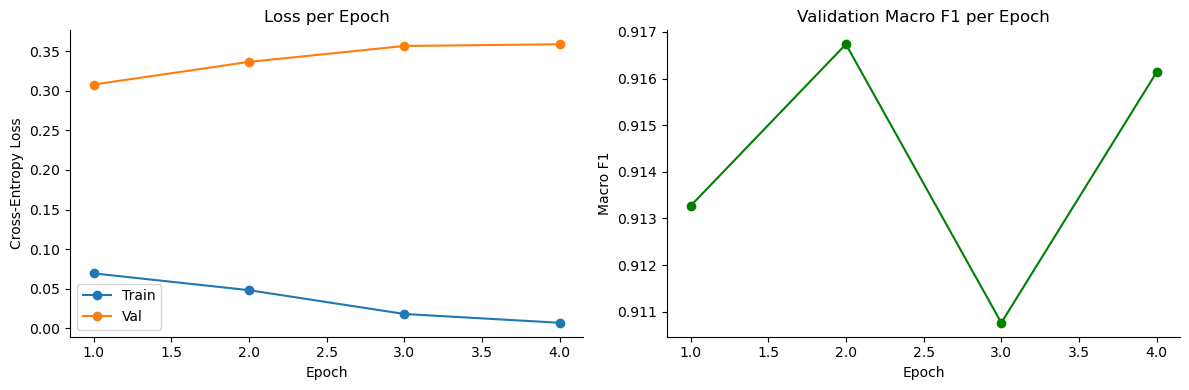

Best validation macro F1: 0.9167


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)
ax1.plot(epochs_range, history['train_loss'], marker='o', label='Train')
ax1.plot(epochs_range, history['val_loss'], marker='o', label='Val')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
sns.despine(ax=ax1)

ax2.plot(epochs_range, history['val_f1'], marker='o', color='green')
ax2.set_title('Validation Macro F1 per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print(f'Best validation macro F1: {best_val_f1:.4f}')

## 9. Evaluation on Test Set

In [34]:
# Load best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
_, _, test_preds, test_labels = evaluate(test_loader)

pred_labels = [ID2LABEL[p] for p in test_preds]
true_labels = [ID2LABEL[l] for l in test_labels]

print('Fine-Tuned DistilBERT — Test Set Performance:')
print('=' * 55)
distilbert_report = classification_report(
    true_labels, pred_labels,
    labels=['positive', 'negative', 'neutral'],
    output_dict=True
)
print(classification_report(
    true_labels, pred_labels,
    labels=['positive', 'negative', 'neutral']
))

Fine-Tuned DistilBERT — Test Set Performance:
              precision    recall  f1-score   support

    positive       0.85      0.79      0.82        89
    negative       0.83      0.90      0.86        42
     neutral       0.93      0.94      0.93       215

    accuracy                           0.90       346
   macro avg       0.87      0.88      0.87       346
weighted avg       0.90      0.90      0.90       346



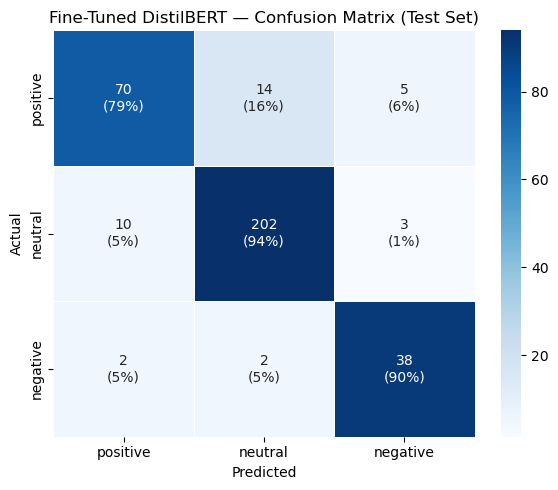

In [36]:
plot_confusion_matrix(true_labels, pred_labels, 'Fine-Tuned DistilBERT — Confusion Matrix (Test Set)')

## 10. Baseline Comparison

Side-by-side comparison of VADER (general-domain, rule-based) vs. fine-tuned DistilBERT (domain-adapted, learned).

In [38]:
# VADER scores are on the full dataset; DistilBERT scores are on the test split
# For a fair comparison, re-evaluate VADER on the same test split
test_vader_preds = test_df['sentence'].apply(vader_predict).tolist()
vader_test_report = classification_report(
    true_labels, test_vader_preds,
    labels=['positive', 'negative', 'neutral'],
    output_dict=True,
    zero_division=0
)

comparison_data = {}
for cls in ['positive', 'negative', 'neutral', 'macro avg']:
    comparison_data[cls] = {
        'VADER F1': round(vader_test_report[cls]['f1-score'], 3),
        'DistilBERT F1': round(distilbert_report[cls]['f1-score'], 3),
        'Δ F1': round(
            distilbert_report[cls]['f1-score'] - vader_test_report[cls]['f1-score'], 3
        ),
    }

comparison_df = pd.DataFrame(comparison_data).T
print('Baseline Comparison (Test Set):')
print(comparison_df.to_string())

Baseline Comparison (Test Set):
           VADER F1  DistilBERT F1   Δ F1
positive      0.515          0.819  0.303
negative      0.273          0.864  0.591
neutral       0.645          0.933  0.288
macro avg     0.478          0.872  0.394


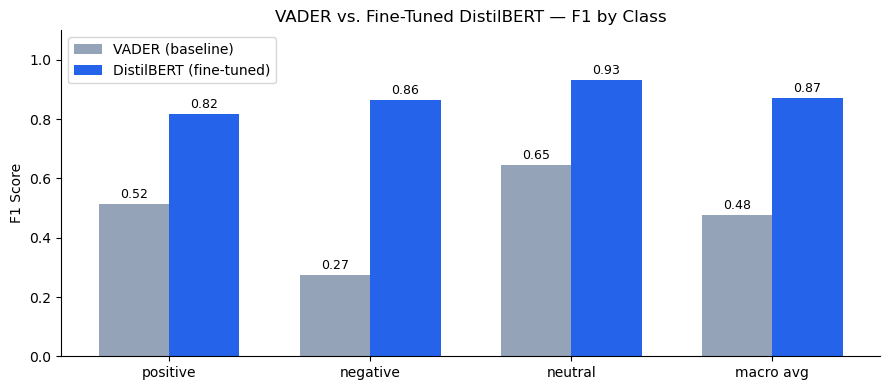

In [40]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comparison_df.index))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['VADER F1'], width, label='VADER (baseline)', color='#94a3b8')
bars2 = ax.bar(x + width/2, comparison_df['DistilBERT F1'], width, label='DistilBERT (fine-tuned)', color='#2563eb')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('VADER vs. Fine-Tuned DistilBERT — F1 by Class')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 11. Error Analysis

Where does the model still fail? Understanding the failure modes is more useful than the aggregate F1 — it tells you whether to collect more data, adjust the label scheme, or accept the limit as a dataset artifact.

In [42]:
error_df = test_df.copy().reset_index(drop=True)
error_df['predicted'] = pred_labels
error_df['correct'] = error_df['label'] == error_df['predicted']

errors = error_df[~error_df['correct']][['sentence', 'label', 'predicted']]
print(f'Total errors: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)')

Total errors: 36 / 346 (10.4%)


In [44]:
# Count error types (true → predicted)
error_types = errors.groupby(['label', 'predicted']).size().reset_index(name='count')
error_types = error_types.sort_values('count', ascending=False)
print('Most common error types (true label → predicted label):')
print(error_types.to_string(index=False))

Most common error types (true label → predicted label):
   label predicted  count
positive   neutral     14
 neutral  positive     10
positive  negative      5
 neutral  negative      3
negative   neutral      2
negative  positive      2


In [46]:
def show_errors(true_label, pred_label, n=4):
    subset = errors[(errors['label'] == true_label) & (errors['predicted'] == pred_label)]
    if len(subset) == 0:
        print(f'No errors: {true_label} → {pred_label}')
        return
    print(f'\nActual: {true_label.upper()} → Predicted: {pred_label.upper()} ({len(subset)} cases)')
    print('-' * 70)
    for sent in subset['sentence'].head(n):
        print(f'  • {sent}')

# The two most common confusion pairs in financial sentiment
show_errors('positive', 'neutral')
show_errors('neutral', 'positive')
show_errors('negative', 'neutral')
show_errors('neutral', 'negative')


Actual: POSITIVE → Predicted: NEUTRAL (14 cases)
----------------------------------------------------------------------
  • Hearst will be able to consolidate about 20 % of all Russian market for advertising in press after the purchase .
  • `` After the share purchase is completed , financing will also be provided to expand Latvia 's broadband infrastructure and to develop new areas of business , including acquisitions of other companies . ''
  • The company turned to earnings per share ( EPS ) of EUR 0.03 versus loss per share of EUR 0.01 .
  • Under the agreement GeoSentric will provide GyPSii-powered hotel information and reservation services to visitors to China , including such popular cities as Beijing and Shanghai .

Actual: NEUTRAL → Predicted: POSITIVE (10 cases)
----------------------------------------------------------------------
  • Aldata noted that its Voice Supply Chain Technology approach enables VDW to integrate with warehouse management systems .
  • Following the 

### Error Analysis Interpretation

**67% of all errors (24/36) are positive ↔ neutral confusions.** Negative is almost perfectly separated: only 4 errors total out of 42 negative test sentences (90% recall).

The positive→neutral failures share a structural pattern — the sentiment is carried by *context the model doesn't have*, not by the sentence itself:
- *"Hearst will be able to consolidate about 20% of all Russian market for advertising in press after the purchase."* — market consolidation is positive, but the sentence reads as a factual future statement.
- *"The company turned to earnings per share of EUR 0.03 versus loss per share of EUR 0.01."* — a turnaround, but stated as a comparison of two numbers with no explicit evaluative language.
- *"After the share purchase is completed, financing will also be provided to expand..."* — expansion is good news; the sentence sounds like a press release boilerplate.

The annotators read these in the context of surrounding articles and marked them positive. The model sees only the sentence. The performance ceiling here is set by the information available at inference time, not model capacity.

The neutral→negative errors reveal a different pattern — **general-register negativity misread as financial negativity**:
- *"Soon after, the collisions started."* — physically negative, financially irrelevant.
- *"High winds also toppled three semi-trailers on I-15 north of Barstow."* — disaster language, but the annotators labelled it neutral from an investor perspective.

The model has learned that collision and disaster language signals negative sentiment, which is correct in most domains. It hasn't learned that *financial* neutrality can coexist with physically negative events.

**Production implication**: use logit confidence, not just the argmax label. The positive/neutral boundary is soft; high-confidence predictions are reliable, borderline ones should be flagged for review.

## Summary

| Model | Positive F1 | Neutral F1 | Negative F1 | **Macro F1** |
|-------|------------|-----------|------------|-------------|
| VADER (baseline) | 0.515 | 0.645 | 0.273 | 0.478 |
| DistilBERT fine-tuned | 0.819 | 0.933 | 0.864 | **0.872** |
| Δ improvement | +0.304 | +0.288 | **+0.591** | **+0.394** |

**Key takeaways:**
1. Domain adaptation works — +39.4 points macro F1 over the rule-based baseline on the same test set.
2. The biggest gain is on **negative** (+0.591): VADER correctly identifies only 28% of negative sentences; DistilBERT identifies 90%. Financial downside language is invisible to a general-domain lexicon.
3. The hardest boundary is **positive ↔ neutral** (24 of 36 errors): this is an information problem, not a model problem — see error analysis above.
4. Encoder-only architecture (DistilBERT) is the right choice for classification; decoder models generate when you need understanding.